# SVM

# Hard-margin SVM 

In [13]:
import numpy as np
import matplotlib.pyplot as plt

class SVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize weights
        self.w = np.zeros(n_features)
        self.b = 0

        # Convert labels from 0 to -1
        y_ = np.where(y <= 0, -1, 1)

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.w) + self.b) >= 1
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                    self.b -= self.lr * y_[idx]

    def predict(self, X):
        approx = np.dot(X, self.w) + self.b
        return np.sign(approx)


In [3]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Generate synthetic 2D linearly separable data
X, y = make_blobs(n_samples=100, centers=2, random_state=6)
y = np.where(y == 0, -1, 1)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train
svm = SVM()
svm.fit(X_train, y_train)
predictions = svm.predict(X_test)

# Accuracy
acc = np.mean(predictions == y_test)
print("Accuracy:", acc)


Accuracy: 1.0


In [6]:
def visualize_svm(model, X, y):
    def get_hyperplane_value(x, w, b, offset):
        return (-w[0] * x + b + offset) / w[1]

    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')

    # X0 range
    x0_1 = np.amin(X[:, 0])
    x0_2 = np.amax(X[:, 0])
    x1_1 = get_hyperplane_value(x0_1, model.w, model.b, 0)
    x1_2 = get_hyperplane_value(x0_2, model.w, model.b, 0)

    x1_1_m = get_hyperplane_value(x0_1, model.w, model.b, -1)
    x1_2_m = get_hyperplane_value(x0_2, model.w, model.b, -1)

    x1_1_p = get_hyperplane_value(x0_1, model.w, model.b, 1)
    x1_2_p = get_hyperplane_value(x0_2, model.w, model.b, 1)

    # Plot decision boundary and margins
    ax.plot([x0_1, x0_2], [x1_1, x1_2], 'k--')      # Decision boundary
    ax.plot([x0_1, x0_2], [x1_1_m, x1_2_m], 'g--')  # Margin -
    ax.plot([x0_1, x0_2], [x1_1_p, x1_2_p], 'g--')  # Margin +

    ax.set_ylim(np.amin(X[:, 1]) - 1, np.amax(X[:, 1]) + 1)
    plt.title("SVM Decision Boundary (Hard Margin)")
    plt.show()


def visualize_svm_soft(model, X, y):
    def get_hyperplane_value(x, w, b, offset):
        return (-w[0] * x + b + offset) / w[1]

    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')

    # X0 range
    x0_1 = np.amin(X[:, 0])
    x0_2 = np.amax(X[:, 0])
    x1_1 = get_hyperplane_value(x0_1, model.w, model.b, 0)
    x1_2 = get_hyperplane_value(x0_2, model.w, model.b, 0)

    x1_1_m = get_hyperplane_value(x0_1, model.w, model.b, -1)
    x1_2_m = get_hyperplane_value(x0_2, model.w, model.b, -1)

    x1_1_p = get_hyperplane_value(x0_1, model.w, model.b, 1)
    x1_2_p = get_hyperplane_value(x0_2, model.w, model.b, 1)

    # Plot decision boundary and margins
    ax.plot([x0_1, x0_2], [x1_1, x1_2], 'k--')      # Decision boundary
    ax.plot([x0_1, x0_2], [x1_1_m, x1_2_m], 'g--')  # Margin -
    ax.plot([x0_1, x0_2], [x1_1_p, x1_2_p], 'g--')  # Margin +

    ax.set_ylim(np.amin(X[:, 1]) - 1, np.amax(X[:, 1]) + 1)
    plt.title("SVM Decision Boundary (soft Margin)")
    plt.show()

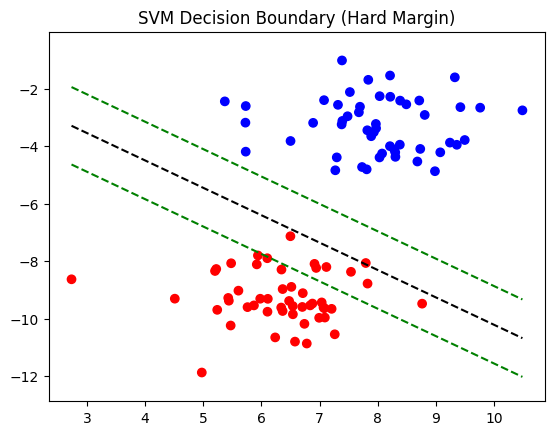

In [5]:
visualize_svm(svm, X, y)

# Soft margin

In [3]:
class SVM_Soft:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000, C=1.0):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.C = C
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        y_ = np.where(y <= 0, -1, 1)

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.w) + self.b) >= 1
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - self.C * np.dot(x_i, y_[idx]))
                    self.b -= self.lr * self.C * y_[idx]


    def predict(self, X):
        approx = np.dot(X, self.w) + self.b
        return np.sign(approx)


In [7]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Generate synthetic 2D linearly separable data
X, y = make_blobs(n_samples=100, centers=2, random_state=6)
y = np.where(y == 0, -1, 1)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train
svm_S = SVM_Soft(C=0.8)# notice the value of C
svm_S.fit(X_train, y_train)
predictions = svm_S.predict(X_test)

# Accuracy
acc = np.mean(predictions == y_test)
print("Accuracy:", acc)


Accuracy: 1.0


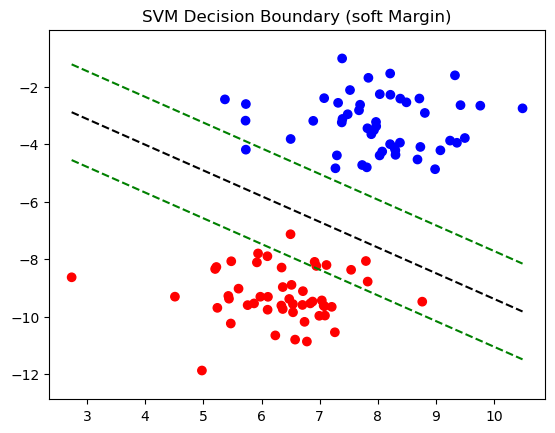

In [8]:
visualize_svm_soft(svm_S, X, y)

# Another example 

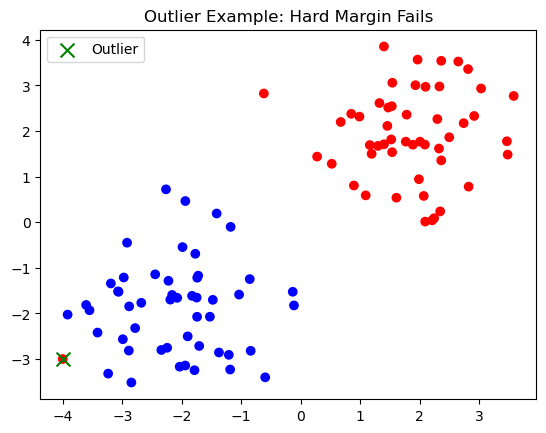

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Create two clusters
np.random.seed(42)
class_1 = np.random.randn(50, 2) + [2, 2]
class_2 = np.random.randn(50, 2) + [-2, -2]

# Add a noisy outlier to class_1 that looks like class_2
outlier = np.array([[ -4, -3 ]])  # Should belong to class_2, but label as class_1

X = np.vstack((class_1, class_2, outlier))
y = np.hstack((np.ones(50), -1*np.ones(50), [1]))  # Label outlier wrongly

# Plot it
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
plt.title("Outlier Example: Hard Margin Fails")
plt.scatter(outlier[0,0], outlier[0,1], color='green', marker='x', s=100, label='Outlier')
plt.legend()
plt.show()



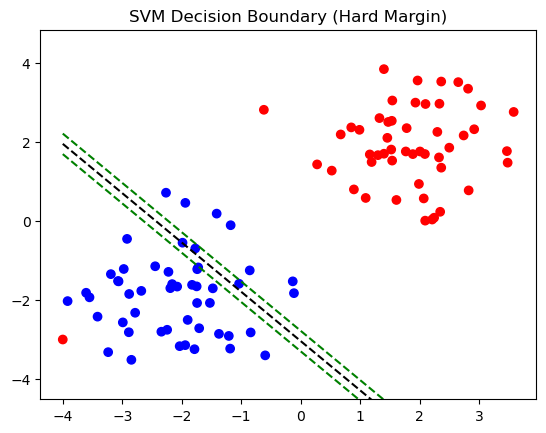

In [14]:
svm_hard = SVM()
svm_hard.fit(X, y)
visualize_svm(svm_hard, X, y)


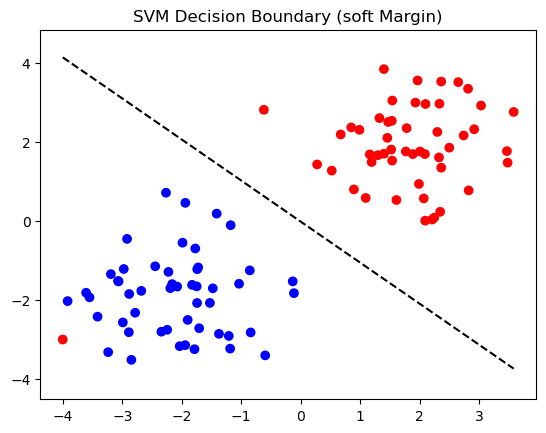

In [11]:
svm_soft = SVM_Soft(C=0.000001)
svm_soft.fit(X, y)
visualize_svm_soft(svm_soft, X, y)

So how to chose the value of C?

High C (e.g., 1000):

    Tries to classify all training points correctly
    Narrow margin, potentially leading to overfitting
    Small tolerance for misclassified points

Low C (e.g., 0.01):

    Allows more misclassifications
    Wider margin, better generalization
    Good for noisy or overlapping data

# Using an inbuilt funciton

In [18]:
def plot_svc_decision_boundary(model, X, y, title):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
    
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Create grid
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    # Get decision function values
    Z = model.decision_function(xy).reshape(XX.shape)

    # Plot margin and decision boundary
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1],
               alpha=0.5, linestyles=['--', '-', '--'])
    plt.title(title)
    plt.show()


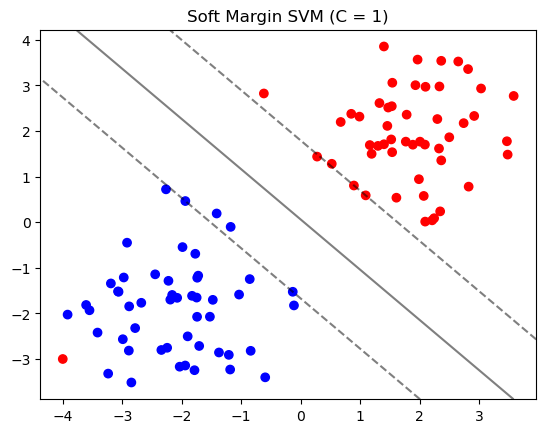

In [19]:
from sklearn.svm import SVC
model_soft = SVC(kernel='linear', C=1)
model_soft.fit(X, y)
plot_svc_decision_boundary(model_soft, X, y, "Soft Margin SVM (C = 1)")


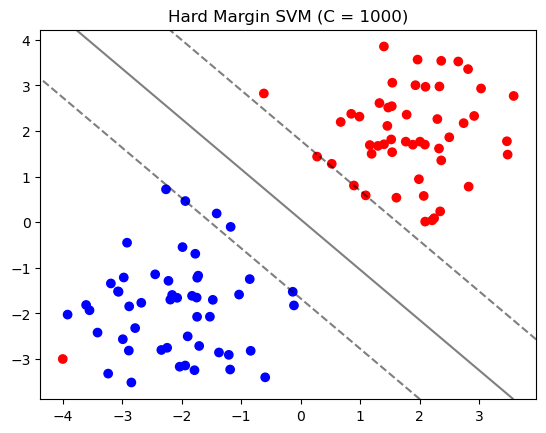

In [20]:
from sklearn.svm import SVC

model_hard = SVC(kernel='linear', C=1000)
model_hard.fit(X, y)
plot_svc_decision_boundary(model_hard, X, y, "Hard Margin SVM (C = 1000)")


In [21]:
#How to Choose C in Practice   - GRID SEARCH
#Use Cross-Validation

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define SVM and parameter grid
svm = SVC(kernel='linear')
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

# Grid search with 5-fold CV
grid = GridSearchCV(svm, param_grid, cv=5)
grid.fit(X, y)

print("Best C value:", grid.best_params_['C'])

Best C value: 0.01


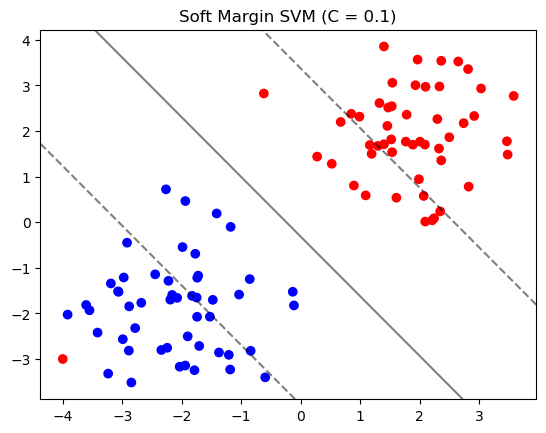

In [22]:
from sklearn.svm import SVC
model_soft = SVC(kernel='linear', C=0.01)
model_soft.fit(X, y)
plot_svc_decision_boundary(model_soft, X, y, "Soft Margin SVM (C = 0.1)")

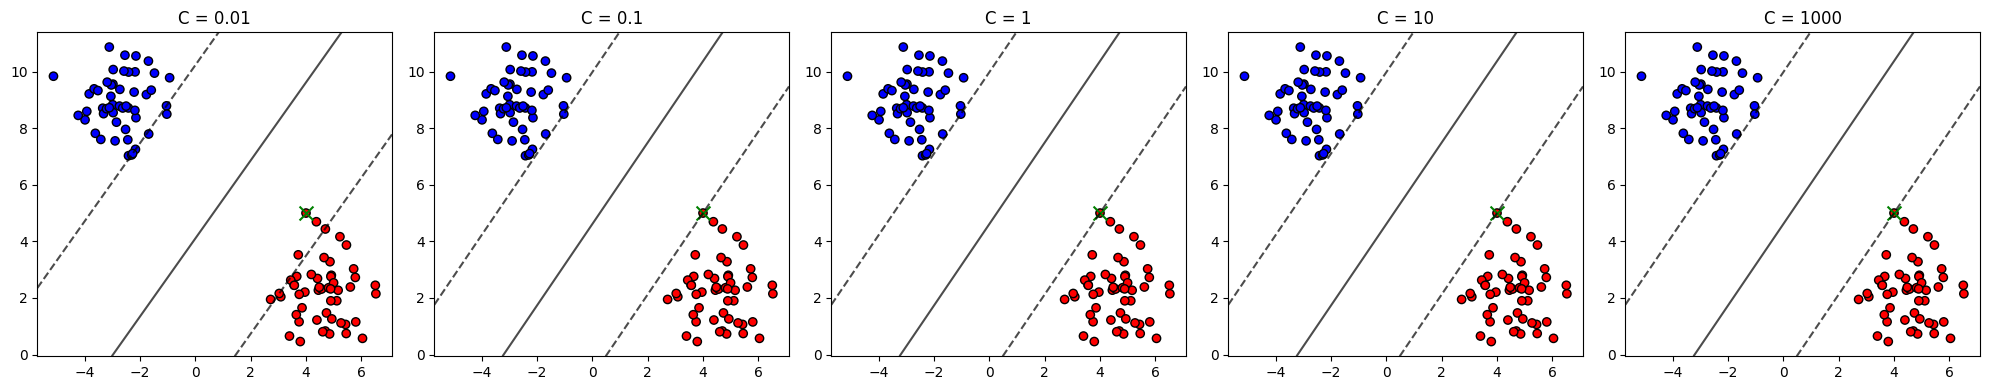

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs

# Step 1: Generate data with an outlier
X, y = make_blobs(n_samples=100, centers=2, cluster_std=1.0, random_state=42)
y = np.where(y == 0, -1, 1)
outlier = np.array([[4, 5]])
X = np.vstack([X, outlier])
y = np.append(y, 1)

# Step 2: Function to plot decision boundaries
def plot_svc_decision_boundary(ax, model, X, y, title):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
    ax.scatter(outlier[0, 0], outlier[0, 1], color='green', marker='x', s=100, label='Outlier')

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 200)
    yy = np.linspace(ylim[0], ylim[1], 200)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1],
               alpha=0.7, linestyles=['--', '-', '--'])
    ax.set_title(title)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

# Step 3: Try multiple C values
C_values = [0.01, 0.1, 1, 10, 1000]
fig, axes = plt.subplots(1, len(C_values), figsize=(20, 4))

for i, C in enumerate(C_values):
    model = SVC(kernel='linear', C=C)
    model.fit(X, y)
    plot_svc_decision_boundary(axes[i], model, X, y, f"C = {C}")

plt.tight_layout()
plt.show()

# on a sample dataset

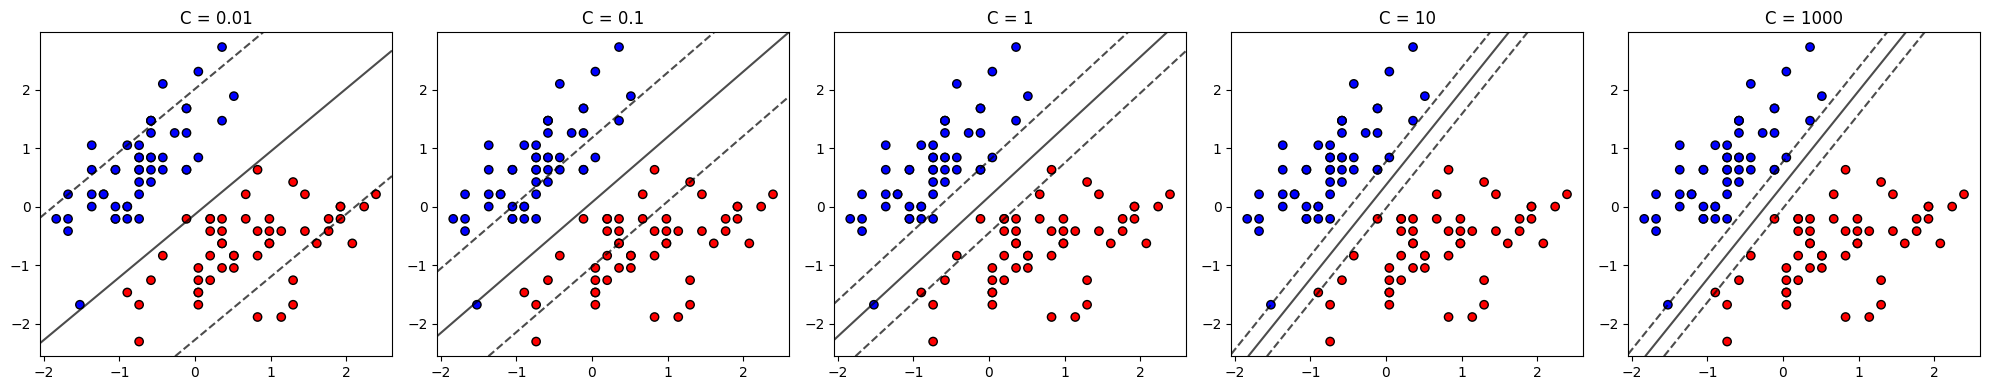

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load iris dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # Only use sepal length and width
y = iris.target

# Only use 2 classes: setosa (0) and versicolor (1)
mask = y < 2
X = X[mask]
y = y[mask]

# Map labels to -1 and +1
y = np.where(y == 0, -1, 1)

# Standardize for better margin visualization
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Helper: Plot SVM boundary
def plot_svc_decision_boundary(ax, model, X, y, title):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 200)
    yy = np.linspace(ylim[0], ylim[1], 200)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1],
               alpha=0.7, linestyles=['--', '-', '--'])
    ax.set_title(title)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

# Try different C values
C_values = [0.01, 0.1, 1, 10, 1000]
fig, axes = plt.subplots(1, len(C_values), figsize=(20, 4))

for i, C in enumerate(C_values):
    model = SVC(kernel='linear', C=C)
    model.fit(X, y)
    plot_svc_decision_boundary(axes[i], model, X, y, f"C = {C}")

plt.tight_layout()
plt.show()
